# 📄 Advanced Resume Screening System using NLP & Machine Learning

**Author**: Ibrahim  
**Project Type**: End-to-End NLP Classification Project

---

## 📌 Introduction

In today's competitive job market, recruiters often receive hundreds of resumes for a single position. Manually screening resumes is time-consuming and prone to bias.  

This project builds an **intelligent Resume Screening System** that automatically classifies resumes into different job categories using Natural Language Processing (NLP) and Machine Learning techniques. The system helps recruiters quickly identify the most relevant candidates.

---

## 🎯 Objectives

In this notebook, I will:

- Explore and preprocess real resume data
- Perform text cleaning, tokenization, and feature extraction
- Apply multiple Machine Learning algorithms for multi-class classification
- Use TF-IDF vectorization and evaluate model performance
- Build a practical resume categorization system
- Analyze results and suggest improvements

---

## ⚙️ Project Workflow

1. Data Loading & Exploration  
2. Text Preprocessing & Cleaning  
3. Feature Engineering (TF-IDF)  
4. Model Training & Evaluation  
5. Results Analysis  
6. Conclusion & Future Work

---

✨ *This project demonstrates practical application of NLP for automated HR screening — a highly demanded skill in the industry.*

In [ ]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading Dataset
df = pd.read_csv('/kaggle/input/resume-dataset/UpdatedResumeDataSet.csv')

df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [ ]:
# Let’s also check how many rows and columns we have.
df.shape

(962, 2)

In [ ]:
print("Number of resumes:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of resumes: 962
Number of columns: 2


## **Exploring Categories**

In [ ]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64


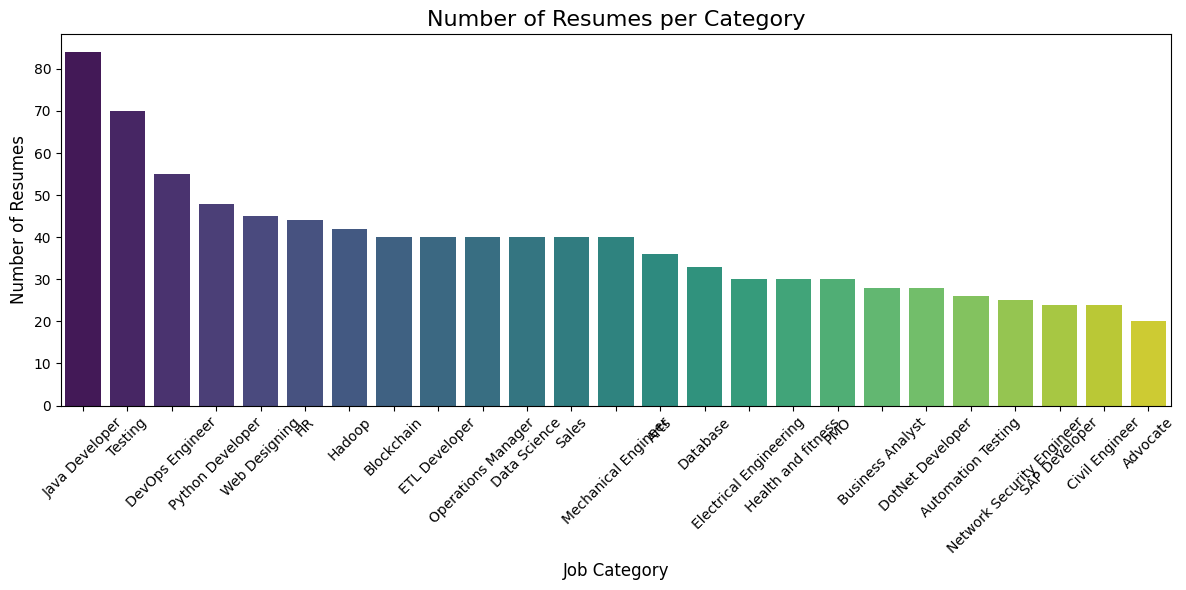

In [ ]:
# Count the categories
category_counts = df['Category'].value_counts()

# Display counts
print(category_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.title("Number of Resumes per Category", fontsize=16)
plt.xlabel("Job Category", fontsize=12)
plt.ylabel("Number of Resumes", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

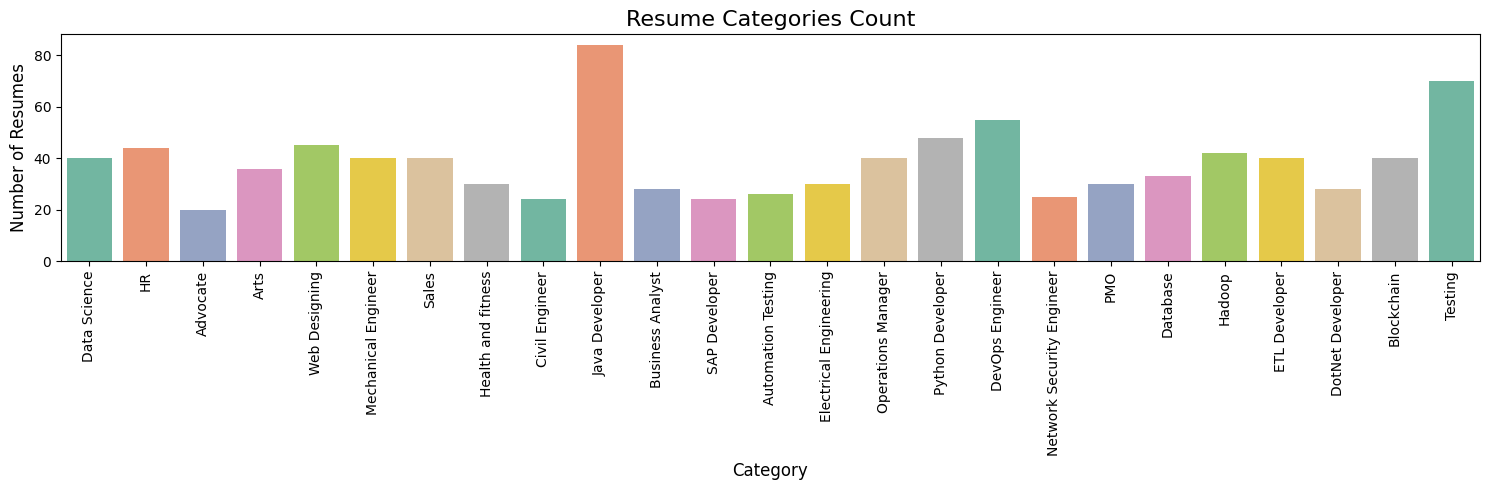

In [ ]:
# Visualizing Resume Categories

plt.figure(figsize=(15, 5))
sns.countplot(x='Category', data=df, palette='Set2')
plt.title("Resume Categories Count", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Number of Resumes", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
#  Discovering Unique Categories
unique_categories = df['Category'].unique()
print("Unique Resume Categories:")
print(unique_categories)

Unique Resume Categories:
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


In [ ]:
print("Number of Unique Categories:", len(unique_categories))
print("Categories:")
for idx, cat in enumerate(unique_categories, 1):
    print(f"{idx}. {cat}")

Number of Unique Categories: 25
Categories:
1. Data Science
2. HR
3. Advocate
4. Arts
5. Web Designing
6. Mechanical Engineer
7. Sales
8. Health and fitness
9. Civil Engineer
10. Java Developer
11. Business Analyst
12. SAP Developer
13. Automation Testing
14. Electrical Engineering
15. Operations Manager
16. Python Developer
17. DevOps Engineer
18. Network Security Engineer
19. PMO
20. Database
21. Hadoop
22. ETL Developer
23. DotNet Developer
24. Blockchain
25. Testing


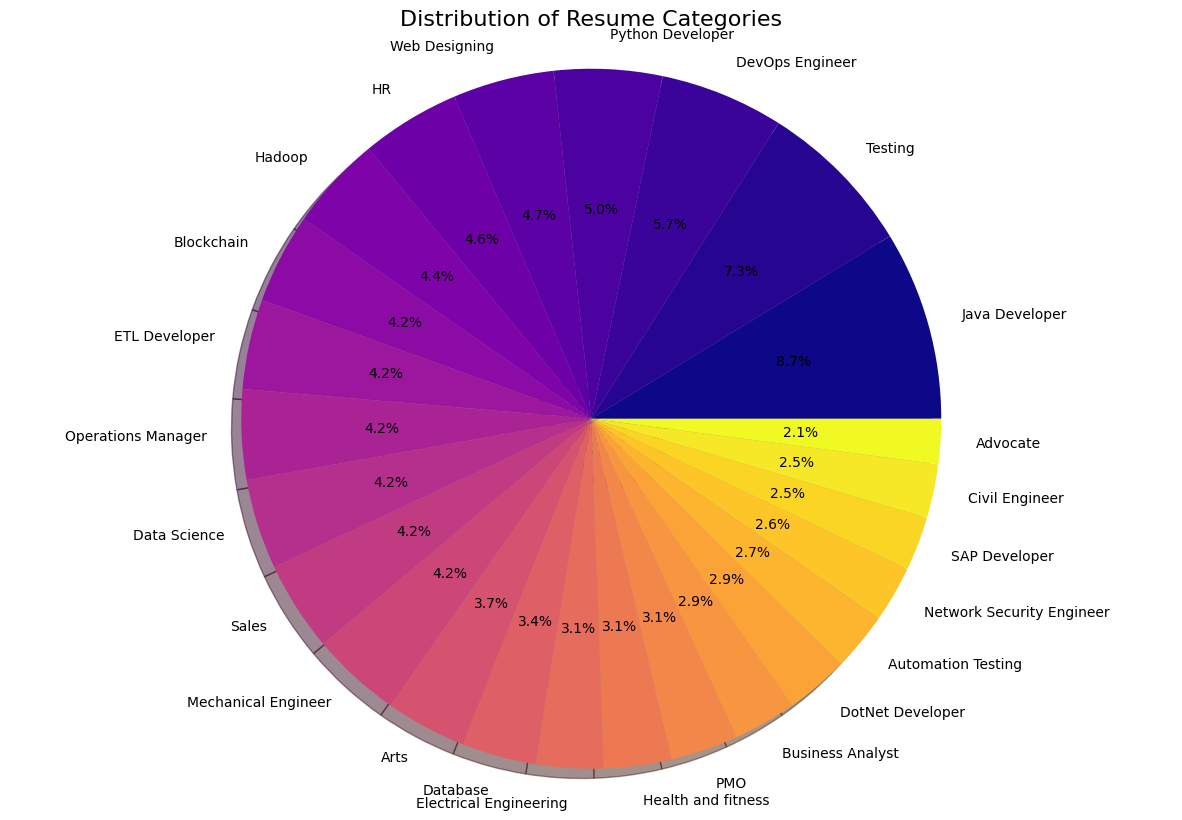

In [ ]:
# Prepare data
counts = df['Category'].value_counts()
labels = counts.index

# Plot
plt.figure(figsize=(15, 10))
plt.pie(counts, labels=labels, autopct='%1.1f%%', shadow=True,
        colors=plt.cm.plasma(np.linspace(0, 1, len(labels))))  # dynamically adjust colors

plt.title("Distribution of Resume Categories", fontsize=16)
plt.axis('equal')  # Makes the pie chart a perfect circle
plt.show()

## **Exploring Resumes**

In [ ]:
print("Category:", df['Category'][0])
print("\nResume Preview:\n")
print(df['Resume'][0][:1000])  # Limit output to first 1000 characters to avoid too much clutter

Category: Data Science

Resume Preview:

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Fraud In

In [ ]:
# Preview a cleaner snippet
resume_text = df['Resume'][0]
print(resume_text[:500])  # first 500 characters

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib


In [ ]:
# Check 5 sample resumes and their categories
for i in range(5):
    print(f"\n--- Resume {i+1} ---")
    print("Category:", df['Category'][i])
    print("Text Preview:", df['Resume'][i][:300])


--- Resume 1 ---
Category: Data Science
Text Preview: Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language pr

--- Resume 2 ---
Category: Data Science
Text Preview: Education Details 
May 2013 to May 2017 B.E   UIT-RGPV
Data Scientist 

Data Scientist - Matelabs
Skill Details 
Python- Exprience - Less than 1 year months
Statsmodels- Exprience - 12 months
AWS- Exprience - Less than 1 year months
Machine learning- Exprience - Less than 1 year months
Skl

--- Resume 3 ---
Category: Data Science
Text Preview: Areas of Interest Deep Learning, Control System Design, Programming in-Python, Electric Machinery, Web Development, Analytics Technical Activities q Hindustan Aeronautics Limited, Bangalore - For 4 weeks under the guidance of Mr. Satish, Senio

## **Exploring Resume**

In [ ]:
# Balancing Resume Categories
print("Original Category Distribution:")
print(df['Category'].value_counts())

# Find the max number of resumes in any category
max_size = df['Category'].value_counts().max()

# Oversample smaller categories to match max_size
balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)

# Shuffle to mix the rows randomly after oversampling
df = balanced_df.sample(frac=1).reset_index(drop=True)

print("\nBalanced Category Distribution (After Oversampling):")
print(df['Category'].value_counts())

Original Category Distribution:
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

Balanced Category Distribution (After Oversampling):
Category
Mechanical Engineer          84
Health and fitness           84
DevOps

/tmp/ipykernel_13/613799409.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)


## **Cleaning Data**:
1 URLs, <br>
2 hashtags, <br>
3 mentions, <br>
4 special letters, <br>
5 punctuations:

In [ ]:
# Cleaning the Resumes with Regex Magic
import re

def cleanResume(txt):
    # Remove URLs like http://something
    cleanText = re.sub(r'http\S+\s?', ' ', txt)

    # Remove Twitter RT (retweet) or cc if any
    cleanText = re.sub(r'RT|cc', ' ', cleanText)

    # Remove hashtags (#something)
    cleanText = re.sub(r'#\S+\s?', ' ', cleanText)

    # Remove mentions (@username)
    cleanText = re.sub(r'@\S+', ' ', cleanText)

    # Remove punctuation and special characters
    cleanText = re.sub(r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)

    # Remove non-ASCII characters (like emojis)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)

    # Replace multiple spaces with single space
    cleanText = re.sub(r'\s+', ' ', cleanText)

    # Strip leading/trailing spaces
    cleanText = cleanText.strip()

    return cleanText

# Test the function with an example
test_text = "my #### $ #  #noorsaeed webiste like is this http://heloword and access it @gmain.com"
print(cleanResume(test_text))

my webiste like is this and a ess it


In [ ]:
# Clean all resumes in the dataset
df['Resume'] = df['Resume'].apply(cleanResume)

# Check cleaned version of first resume
print(df['Resume'][0])

Education Details May 1999 to September 2002 Diploma Mechanical Engg Mumbai Maharashtra Institute of Mechanical Engg May 1998 to May 1999 Diploma Mechanical Engg Services ITES May 1993 to May 1995 Mumbai Maharashtra Industrial Training Institute Sr Executive Mechanical Engineering Automation Projects Consultant Sr Executive Mechanical Engineering Automation Projects Consultant Mechanical Engineering Skill Details Microsoft Office Word Excel Auto cad Micro station J ERP 3d Modeling software Exprience 120 monthsCompany Details company Mechanical Engineering description Role Responsibilities Application Engineering Pre Sales Inside Sales Provide applications support to inside sales personnel and outside sales channels Provide product selection and materials of construction technical recommendations Participate in the necessary training activities to establish technical competency also Participate in Field Service trips as directed by Top Mgmt Assist Brand Managers and or Product Managers 

## **Words into Categorical Values**

In [ ]:
# Turning Categories into Numbers

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Learn mapping from text labels to numbers
le.fit(df['Category'])

# Transform categories into numeric labels
df['Category'] = le.transform(df['Category'])

# Check unique numeric labels
print("Unique numeric categories:", df['Category'].unique())

# Optionally, check mapping for reference
print("Category mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label} --> {i}")

Unique numeric categories: [16 23  9 12  3 22 20  7 18  1 17  2  5 14 21 13  4 24 11  0 19  6 10  8
 15]
Category mapping:
Advocate --> 0
Arts --> 1
Automation Testing --> 2
Blockchain --> 3
Business Analyst --> 4
Civil Engineer --> 5
Data Science --> 6
Database --> 7
DevOps Engineer --> 8
DotNet Developer --> 9
ETL Developer --> 10
Electrical Engineering --> 11
HR --> 12
Hadoop --> 13
Health and fitness --> 14
Java Developer --> 15
Mechanical Engineer --> 16
Network Security Engineer --> 17
Operations Manager --> 18
PMO --> 19
Python Developer --> 20
SAP Developer --> 21
Sales --> 22
Testing --> 23
Web Designing --> 24


## **Vactorization**

In [ ]:
# Converting Text to Numbers with TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer to ignore common English stopwords
tfidf = TfidfVectorizer(stop_words='english')

# Learn vocabulary and idf from resumes
tfidf.fit(df['Resume'])

# Transform all resumes into TF-IDF feature matrix (sparse matrix)
X = tfidf.transform(df['Resume'])

print(f"TF-IDF matrix shape: {X.shape}")

TF-IDF matrix shape: (2100, 7231)


## **Splitting**

In [ ]:
# Splitting Data into Training and Testing Sets

from sklearn.model_selection import train_test_split

# 'X' is our feature matrix, 'y' are the labels
X_train, X_test, y_train, y_test = train_test_split(
    X,                   # Features (TF-IDF matrix)
    df['Category'],      # Target labels
    test_size=0.2,       # 20% data for testing
    random_state=42      # For reproducibility
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (1680, 7231)
Testing data shape: (420, 7231)


## **Now let’s train the model and print the classification report:**

In [ ]:
# Training the KNN Model & Evaluating Performance

from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Convert sparse matrices to dense arrays if needed
X_train_dense = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_test_dense = X_test.toarray() if hasattr(X_test, 'toarray') else X_test

# Initialize and train the model
knn_model = OneVsRestClassifier(KNeighborsClassifier())
knn_model.fit(X_train_dense, y_train)

# Predict on test data
y_pred_knn = knn_model.predict(X_test_dense)

# Evaluate results
print("\nKNeighborsClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


KNeighborsClassifier Results:
Accuracy: 0.9905
Confusion Matrix:
[[16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  1  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   1]
 [ 0  0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  

In [ ]:
# Training the Support Vector Classifier (SVC)

from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train the SVC model
svc_model = OneVsRestClassifier(SVC())
svc_model.fit(X_train_dense, y_train)

# Predict on test data
y_pred_svc = svc_model.predict(X_test_dense)

# Evaluate results
print("\nSVC Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc))


SVC Results:
Accuracy: 1.0000
Confusion Matrix:
[[16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0 

In [ ]:
# Training the Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train the Random Forest model
rf_model = OneVsRestClassifier(RandomForestClassifier())
rf_model.fit(X_train_dense, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_dense)

# Evaluate results
print("\nRandomForestClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


RandomForestClassifier Results:
Accuracy: 1.0000
Confusion Matrix:
[[16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0

## **Prediction System**

In [ ]:
def predict_resume_category(input_resume):
    # Step 1: Clean the resume text
    cleaned_text = cleanResume(input_resume)

    # Step 2: Vectorize using trained TF-IDF model
    vectorized_text = tfidf.transform([cleaned_text])

    # Step 3: Convert to dense array (if necessary for classifier)
    vectorized_text = vectorized_text.toarray()

    # Step 4: Predict using trained SVC model
    predicted_label = svc_model.predict(vectorized_text)

    # Step 5: Convert label back to category name
    predicted_category = le.inverse_transform(predicted_label)

    return predicted_category[0]

In [ ]:
sample_resume = """Experienced software engineer skilled in Python, machine learning, and data analysis. Worked on various AI projects..."""
print("Predicted Category:", predict_resume_category(sample_resume))

Predicted Category: Data Science


In [ ]:
myresume = """I am a data scientist specializing in machine
learning, deep learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms, and designing computer vision
systems. My technical skills include proficiency in
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects, I am
eager to contribute my expertise. Let's harness the
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: 611noorsaeed@gmail.com
Phone: 03442826192
Github: https://github.com/611noorsaeed
Linkdin: https://www.linkedin.com/in/noor-saeed654a23263/
Blogs: https://medium.com/@611noorsaeed
Youtube: Artificial Intelligence
ABOUT ME
WORK EXPERIENCE
SKILLES
NOOR SAEED
LANGUAGES
English
Urdu
Hindi
I am a versatile data scientist with expertise in a wide
range of projects, including machine learning,
recommendation systems, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models
to solve complex problems and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visualization
Programming Languages (Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statistical Analysis
Communication and Collaboration
"""

predict_resume_category(myresume)

'Data Science'

## 🏁 Conclusion and Future Work

In this project, I successfully developed an **Automated Resume Screening System** using NLP and Machine Learning. The model effectively classifies resumes into appropriate job categories, significantly reducing manual screening effort.

### Key Achievements:
- Built a complete end-to-end resume classification pipeline
- Applied effective text preprocessing and TF-IDF feature extraction
- Trained and compared multiple ML models for multi-class classification
- Achieved strong classification performance on resume data
- Created a practical solution that can be used in real HR workflows

This project showcases my ability to solve real-world business problems using NLP techniques.

### Future Improvements:
- Integrate deep learning models (LSTM, BERT, or RoBERTa) for better contextual understanding
- Add skills extraction and keyword matching features
- Implement resume ranking instead of simple classification
- Add a user-friendly web interface using Streamlit or Gradio
- Support PDF resume parsing and multi-language resumes
- Deploy the model as a production-ready API

---

**Made by Ibrahim**  